## EXPERIMENT 5

#### AIM: Build Naïve Bayes and Decision Tree classification models and evaluate their performance using appropriate metrics

In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv(r'C:\Users\praty\Documents\ML_Github\datasets\thyroid.csv')
data.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [3]:
data.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

In [5]:
data.isnull().sum()

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

In [6]:
data.rename(columns={'Hx Smoking': 'Smoking History',
                   'Hx Radiothreapy': 'Radiotherapy History',
                   'Pathology': 'Types of Thyroid Cancer (Pathology)',
                   'T': 'Tumor',
                   'N': 'Lymph Nodes',
                   'M': 'Cancer Metastasis',
                  'Response' : 'Treatment Response'}, inplace=True)

In [7]:
data['Adenopathy'].replace({'No' : 'No Lympth Adenopathy' ,
                          'Left' : 'Left Side Body Adenopathy' ,
                          'Right' : 'Right Side Body Adenopathy' ,
                          'Extensive' : 'Extensive and Widespread'}, inplace = True)

data['Stage'].replace({'I' : 'First-Stage' , 'II' : 'Second-Stage' , 'III' : 'Third-Stage'} ,inplace = True)

data['Tumor'].replace({'T1a' : 'tumor that is 1 cm or smaller' , 'T1b' : 'tumor larger than 1 cm but not larger than 2 cm' ,
                     'T2' : 'tumor larger than 2 cm but not larger than 4 cm' , 
                     'T3a' : 'tumor larger than 4 cm' ,'T3b' : 'tumor that has grown outside the thyroid' ,
                     'T4a' : 'tumor that has invaded nearby structures' ,
                        'T4b' : 'tumor that has invaded nearby structures'} , inplace =True)

data['Lymph Nodes'].replace({'N0' : 'no evidence of regional lymph node metastasis' ,
                     'N1b' : 'regional lymph node metastasis in the central  of the neck' ,
                     'N1a' : 'regional lymph node metastasis in the lateral of the neck'} , inplace =True)

data['Cancer Metastasis'].replace({'M0': 'no evidence of distant metastasis' , 'M1' : 'the presence of distant metastasis'} ,inplace =True )
data['Cancer Metastasis'].replace({'M0': 'no evidence of distant metastasis' , 'M1' : 'the presence of distant metastasis'} ,inplace =True )

C:\Users\praty\AppData\Local\Temp\ipykernel_9160\4065030082.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Adenopathy'].replace({'No' : 'No Lympth Adenopathy' ,
C:\Users\praty\AppData\Local\Temp\ipykernel_9160\4065030082.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

0       no evidence of distant metastasis
1       no evidence of distant metastasis
2       no evidence of distant metastasis
3       no evidence of distant metastasis
4       no evidence of distant metastasis
                      ...                
378    the presence of distant metastasis
379    the presence of distant metastasis
380    the presence of distant metastasis
381     no evidence of distant metastasis
382     no evidence of distant metastasis
Name: Cancer Metastasis, Length: 383, dtype: str

C:\Users\praty\AppData\Local\Temp\ipykernel_9160\2150346294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tumor', y='Age', data=data, palette="OrRd", ax=axes[0])
C:\Users\praty\AppData\Local\Temp\ipykernel_9160\2150346294.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y='Age', data=data,palette="OrRd", ax=axes[1])


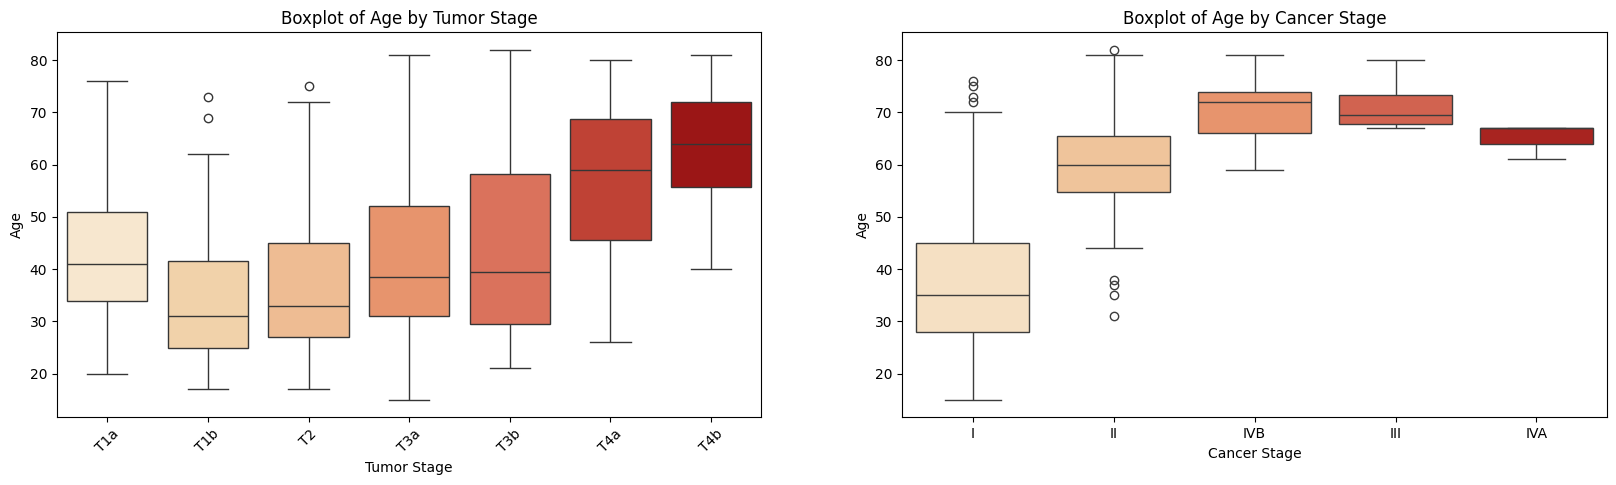

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a 1x2 grid for the plots
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Boxplot for Tumor
sns.boxplot(x='Tumor', y='Age', data=data, palette="OrRd", ax=axes[0])
axes[0].set_title('Boxplot of Age by Tumor Stage') 
axes[0].set_xlabel('Tumor Stage')
axes[0].set_ylabel('Age')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot for Stage
sns.boxplot(x='Stage', y='Age', data=data,palette="OrRd", ax=axes[1])
axes[1].set_title('Boxplot of Age by Cancer Stage')
axes[1].set_xlabel('Cancer Stage')
axes[1].set_ylabel('Age')
axes[1].tick_params(axis='x', rotation=0)

plt.show()

In [9]:
def map_risk_to_percentage(risk):
    if risk == 'Low':
        return 1
    elif risk == 'Intermediate':
        return 2
    else:
        return 3

# Apply the function to create the new column
data['Risk Rate (Out of 3)'] = data['Risk'].apply(map_risk_to_percentage)

In [10]:
pd.set_option('display.max_columns', None)
pivot_table = pd.pivot_table(data, values='Risk Rate (Out of 3)', index=['Stage', 'Smoking'], columns='Age', fill_value=None).round(1)
pivot_table

Age             15   17   18   19   20   21   22   23   24   25   26   27  \
Stage Smoking                                                               
I     No       2.0  2.0  2.0  1.0  1.5  1.2  1.2  1.2  1.1  1.1  1.3  1.2   
      Yes      NaN  NaN  NaN  NaN  NaN  1.0  NaN  NaN  NaN  NaN  3.0  NaN   
II    No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
III   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVA   Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVB   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

Age             28   29   30   31   32   33   34   35   36   37   38   39  \
Stage Smoking                                                               
I     No       1.1  1.2  1.2  1.4  1.4  1.2  1.6  1.4  1.3  1.2  1.1  1.0   
      Yes      1.0  1.0  NaN  1.2  NaN  NaN  NaN  NaN  NaN  NaN  2.0  NaN   
II    No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  2.0  3.0  NaN   
      Yes      NaN  NaN  NaN  3.0  NaN  NaN  NaN  3.0  NaN  NaN  NaN  NaN   
III   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVA   Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVB   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

Age             40   41   42   43   44   45   46   47   48   49   50   51  \
Stage Smoking                                                               
I     No       1.3  1.0  1.2  1.0  1.3  1.1  1.2  1.5  1.8  1.8  1.2  1.2   
      Yes      2.0  2.0  NaN  NaN  1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
II    No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  3.0   
      Yes      NaN  NaN  NaN  NaN  3.0  NaN  3.0  NaN  NaN  NaN  NaN  NaN   
III   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVA   Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVB   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

Age             52   53   54   55   56   57   58   59   60   61   62   63  \
Stage Smoking                                                               
I     No       1.0  2.3  1.0  1.0  1.0  1.0  NaN  1.0  1.2  1.0  1.2  1.0   
      Yes      1.2  NaN  NaN  NaN  2.0  1.0  NaN  2.0  NaN  NaN  NaN  NaN   
II    No       NaN  NaN  NaN  2.0  2.5  NaN  2.0  NaN  2.0  2.0  2.0  2.0   
      Yes      NaN  NaN  2.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  2.0   
III   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
IVA   Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  3.0  NaN  NaN   
IVB   No       NaN  NaN  NaN  NaN  NaN  NaN  NaN  3.0  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  3.0  NaN   

Age             64   65   66   67   68   69   70   71   72   73   75   76  \
Stage Smoking                                                               
I     No       NaN  NaN  1.0  1.0  1.0  1.0  1.0  NaN  1.0  1.0  1.0  1.0   
      Yes      NaN  NaN  NaN  1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
II    No       NaN  2.0  NaN  2.0  NaN  NaN  NaN  NaN  NaN  2.0  NaN  NaN   
      Yes      NaN  NaN  NaN  2.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
III   No       NaN  NaN  NaN  3.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
      Yes      NaN  NaN  NaN  NaN  2.0  NaN  NaN  3.0  NaN  NaN  NaN 

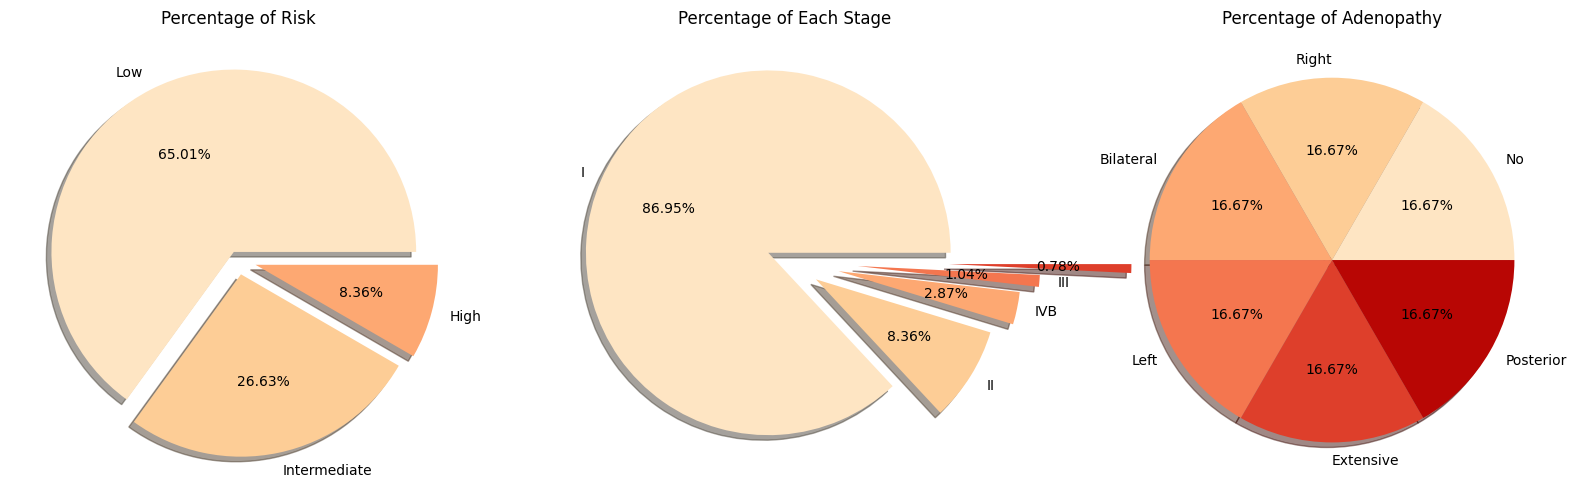

In [11]:
sns.set_palette("OrRd")
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Pie chart for 'Risk'
risky = data['Risk'].value_counts()
risky.plot(kind='pie', autopct='%0.2f%%', explode=[0.05, 0.08, 0.1], labels=risky.index, shadow=True, ax=axes[0])
axes[0].set_title('Percentage of Risk')
axes[0].set_ylabel('')

# Pie chart for 'Stage'
Stage_of_Cancer = data['Stage'].value_counts()
Stage_of_Cancer.plot(kind='pie', autopct='%0.2f%%', labels=Stage_of_Cancer.index, explode=[0.1, 0.2, 0.3, 0.4, 0.9], shadow=True, ax=axes[1])
axes[1].set_title('Percentage of Each Stage')
axes[1].set_ylabel('')
aden = data['Adenopathy'].value_counts()
aden.value_counts().plot(kind='pie', autopct='%0.2f%%', labels=aden.index, shadow=True, ax=axes[2])
axes[2].set_title('Percentage of Adenopathy')
axes[2].set_ylabel('')


plt.show()

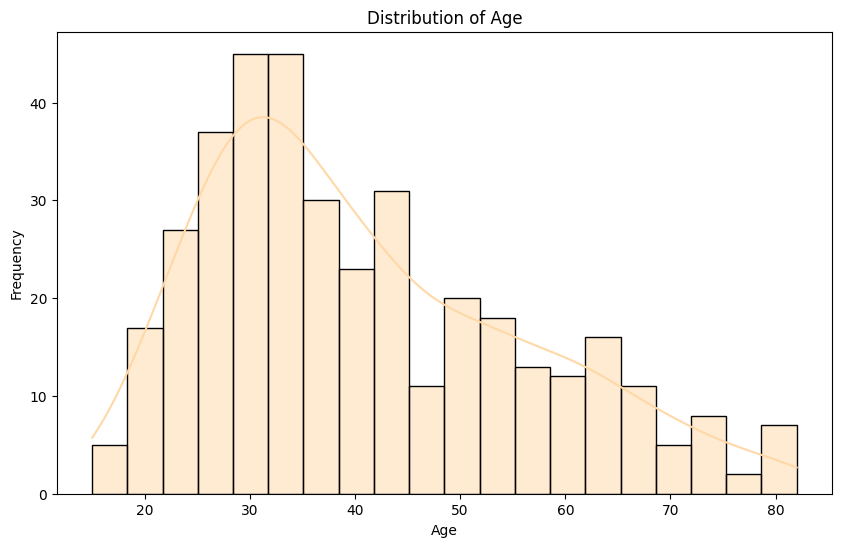

In [12]:
# Visualize the distribution of ages using a histogram.
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=20, kde=True, color='#ffd8a7')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

C:\Users\praty\AppData\Local\Temp\ipykernel_9160\3992538997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=data, palette='OrRd', ax=axes[0])
C:\Users\praty\AppData\Local\Temp\ipykernel_9160\3992538997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Smoking', data=data, palette='OrRd', ax=axes[1])
C:\Users\praty\AppData\Local\Temp\ipykernel_9160\3992538997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Treatment Response', data=data, palette='OrRd',  ax=axes[2])


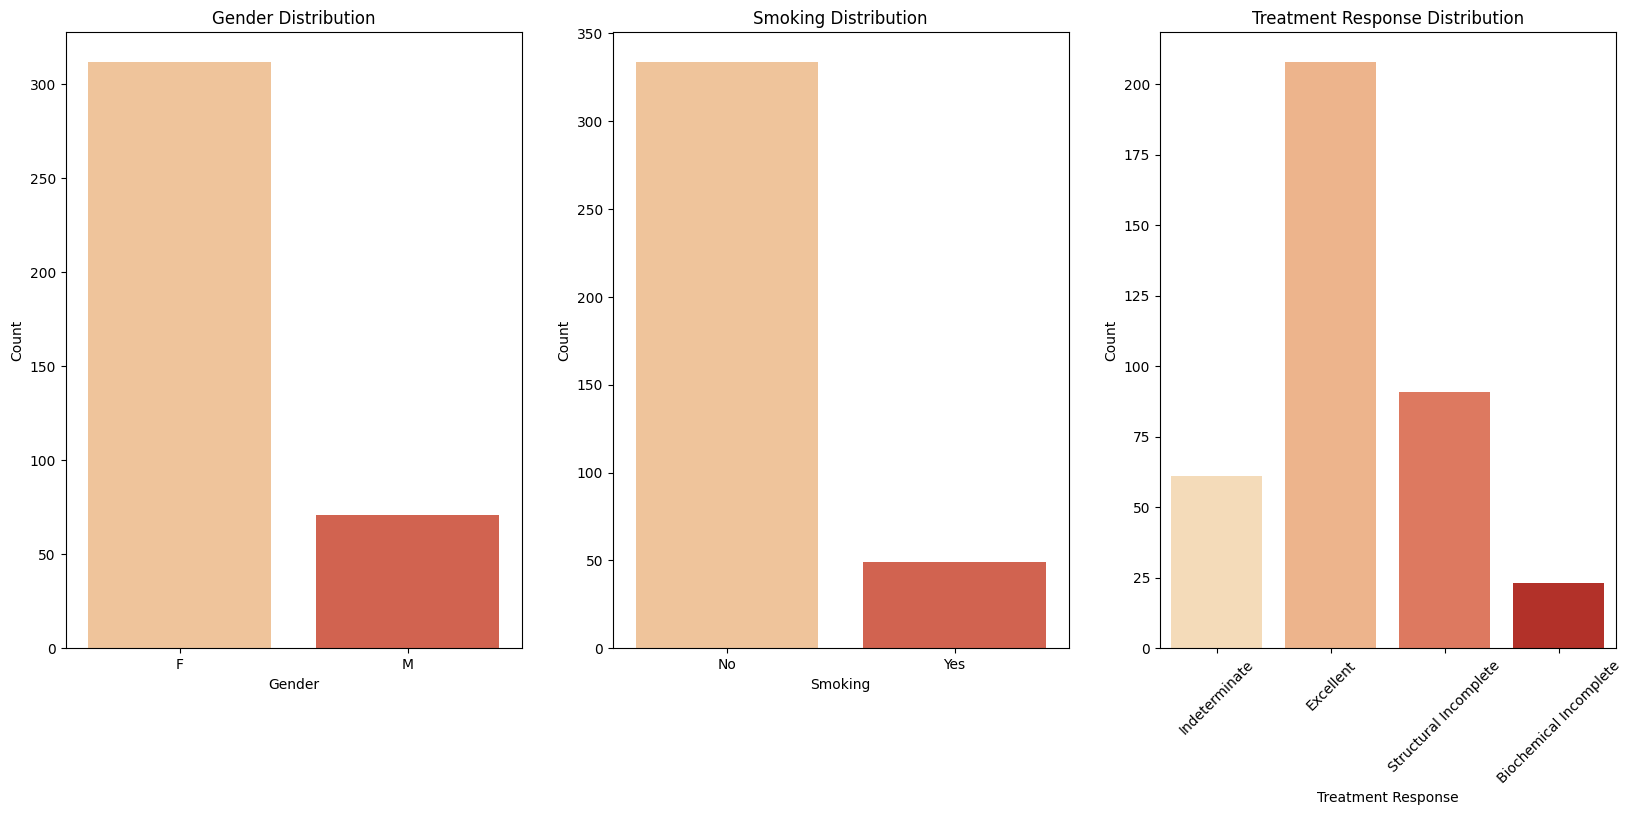

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

#Display the count of patients in each gender category.
sns.countplot(x='Gender', data=data, palette='OrRd', ax=axes[0])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

sns.countplot(x='Smoking', data=data, palette='OrRd', ax=axes[1])
axes[1].set_title('Smoking Distribution')
axes[1].set_xlabel('Smoking')
axes[1].set_ylabel('Count')

sns.countplot(x='Treatment Response', data=data, palette='OrRd',  ax=axes[2])
axes[2].set_title('Treatment Response Distribution')
axes[2].set_xlabel('Treatment Response')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
plt.show()

C:\Users\praty\AppData\Local\Temp\ipykernel_9160\2822748359.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Adenopathy', bbox_to_anchor=(1.05, 1), loc='upper left')


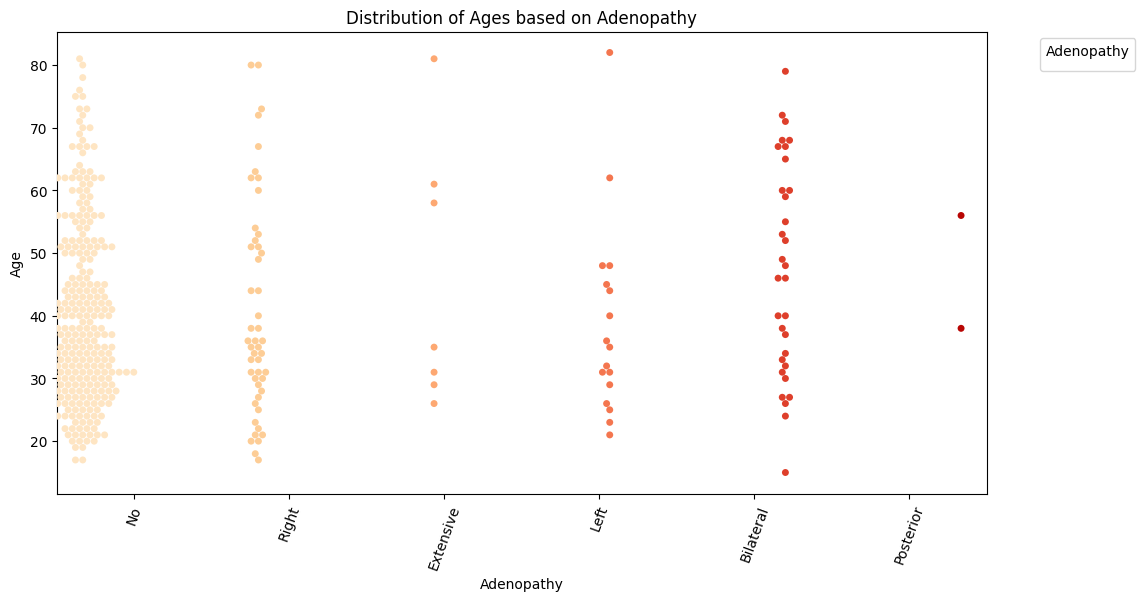

In [14]:
#the distribution of ages based on the presence and location of adenopathy using a swarm plot.
plt.figure(figsize=(12, 6))
sns.swarmplot(x='Adenopathy', y='Age', data=data, palette='OrRd', hue='Adenopathy', dodge=True)
plt.title('Distribution of Ages based on Adenopathy')
plt.xlabel('Adenopathy')
plt.ylabel('Age')
plt.xticks(rotation=70)
plt.legend(title='Adenopathy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C:\Users\praty\AppData\Local\Temp\ipykernel_9160\1124226422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Risk', y='Age', data=data, palette='OrRd', inner='quartile')


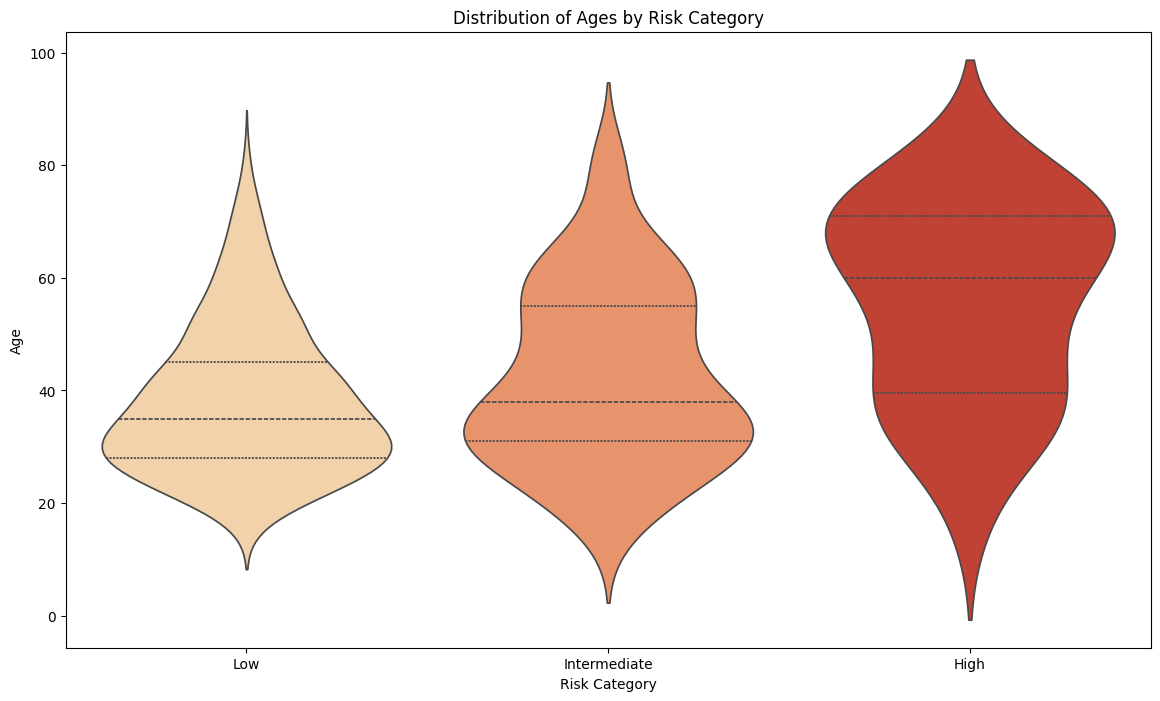

In [15]:
plt.figure(figsize=(14, 8))
sns.violinplot(x='Risk', y='Age', data=data, palette='OrRd', inner='quartile')
plt.title('Distribution of Ages by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Age')
plt.show()

In [16]:
data = pd.get_dummies(data, drop_first=True)

In [17]:
X = data.drop("Recurred_Yes", axis=1)
y = data["Recurred_Yes"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [20]:
y_pred_nb = nb_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.948051948051948

Confusion Matrix:
[[57  1]
 [ 3 16]]

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.98      0.97        58
        True       0.94      0.84      0.89        19

    accuracy                           0.95        77
   macro avg       0.95      0.91      0.93        77
weighted avg       0.95      0.95      0.95        77



In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [23]:
y_pred_dt = dt_model.predict(X_test)

In [24]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.922077922077922

Confusion Matrix:
[[54  4]
 [ 2 17]]

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.93      0.95        58
        True       0.81      0.89      0.85        19

    accuracy                           0.92        77
   macro avg       0.89      0.91      0.90        77
weighted avg       0.93      0.92      0.92        77



In [25]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Naive Bayes Accuracy: 0.948051948051948
Decision Tree Accuracy: 0.922077922077922


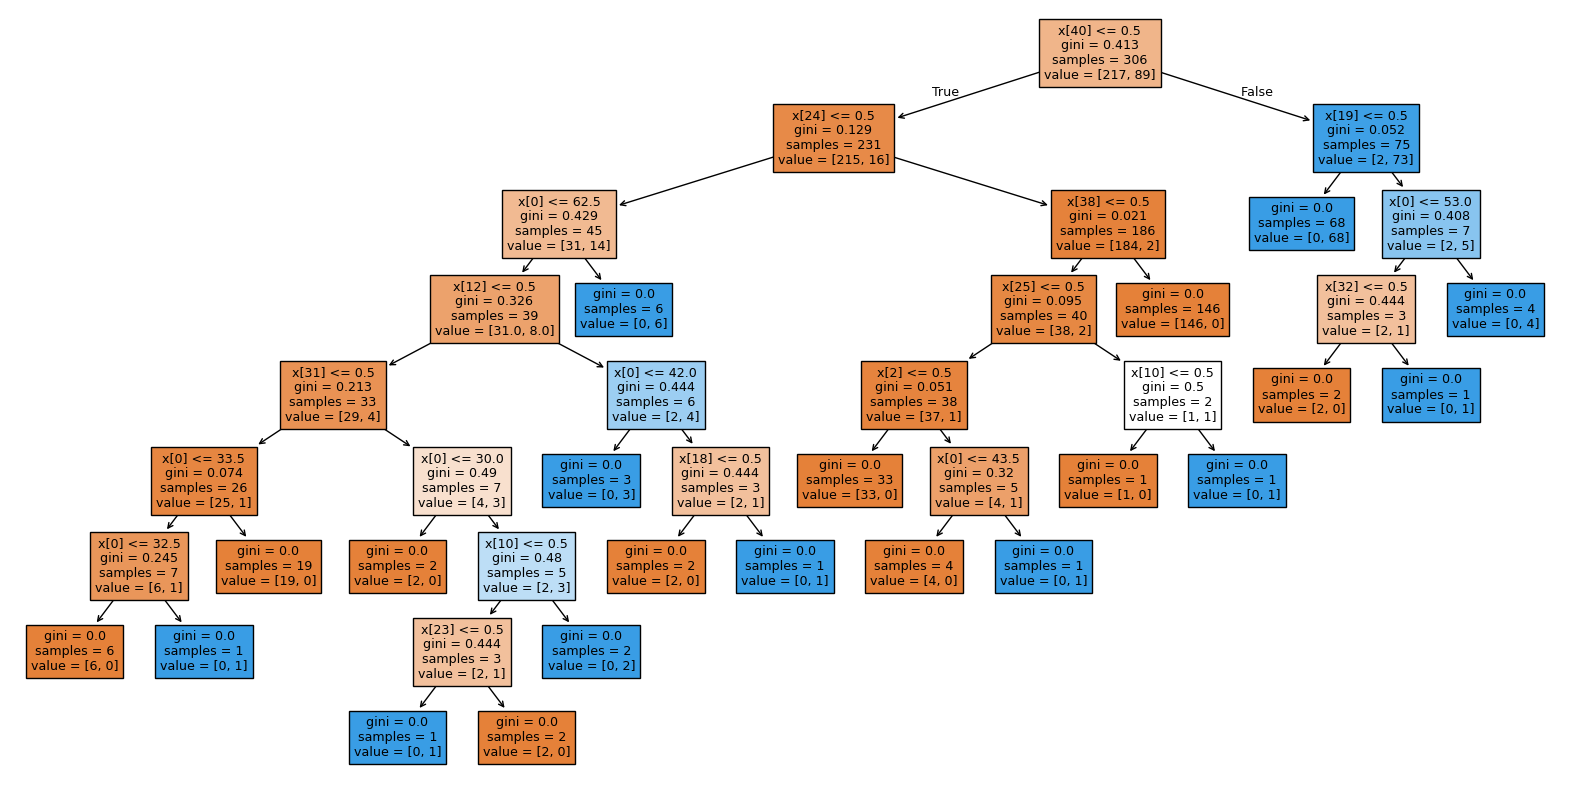

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True)
plt.show()

In [27]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Naive Bayes Accuracy: 0.948051948051948
Decision Tree Accuracy: 0.922077922077922
